# Clements & Denolle (2023) — `codameter` pipeline demo

This notebook runs the `codameter` pipeline against station **CI.LJR** using
real dv/v measurements and PRISM meteorological data from the
[Clements & Denolle (2023)](https://doi.org/10.1029/2022JB025553) study.

Set `DATA_DIR = None` in the configuration cell to fall back to **synthetic mode**
(no data required; useful for testing / CI).

### Data source
```
Clements & Denolle (2023). The seismic signature of California's earthquakes, droughts, and floods.
JGR Solid Earth, 128, e2022JB025553. DOI: 10.1029/2022JB025553
Data: https://doi.org/10.5281/zenodo.6413275
```

In [14]:
from __future__ import annotations
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import pyarrow as pa
import pyarrow.feather as feather

%matplotlib inline
plt.rcParams.update({"figure.dpi": 130, "figure.figsize": (12, 4)})

from codameter import Site, run_workflow
from codameter.config import (
    AnalysisConfig, ForcingSpec, Forcings, Layer, Location,
    MaterialProperties, Measurement, Prior, VelocityModel,
)
from codameter.data.loaders import load_clements_denolle_2023, load_csv_timeseries
from codameter.forward.poroelastic import groundwater_level_okubo
from codameter.forward.thermoelastic import thermoelastic_dvv

print(f"codameter imported OK — Python {sys.version.split()[0]}")

codameter imported OK — Python 3.12.13


## Configuration

Set `DATA_DIR` to the folder containing `CI.LJR.arrow` and the companion
`PRECIP_PATH` / `TEMP_PATH` NetCDF files.  
Set `DATA_DIR = None` to fall back to **synthetic mode** (no data required).

In [15]:
STATION    = "CI.LJR"
DATA_DIR   = Path("/Users/marinedenolle/Downloads/data/DVV-90-DAY-COMP/2.0-4.0")
PRECIP_PATH = Path("/Users/marinedenolle/Downloads/data/PRECIP-LJR.nc")
TEMP_PATH   = Path("/Users/marinedenolle/Downloads/data/tmean.nc")
OUT_DIR    = Path("runs/cd2023_real")
SEED       = 17

OUT_DIR.mkdir(parents=True, exist_ok=True)

## 1 · Build the CI.LJR site configuration

In [16]:
site = Site(
    site_id=f"cd2023_{STATION.replace('.', '_')}",
    location=Location(lat=34.55, lon=-117.77, elevation_m=830.0),
    measurement=Measurement(
        type="cross_correlation", frequency_band_hz=(2.0, 4.0),
    ),
    velocity_model=VelocityModel(
        layers=[
            Layer(thickness_km=0.20, vp=2.0, vs=0.8, rho=2.1),
            Layer(thickness_km=1.50, vp=4.0, vs=2.2, rho=2.4),
            Layer(thickness_km=5.00, vp=5.5, vs=3.1, rho=2.6),
            Layer(thickness_km=50.0, vp=6.2, vs=3.6, rho=2.8),
        ],
    ),
    forcings=Forcings(
        thermoelastic=ForcingSpec(
            enabled=True, model="phase_shift",
            extra={"time_shift_days": 50.0},
        ),
        # Hydrological model — choose one of:
        #   "okubo_gwl"  exponential-decay GWL proxy (Okubo et al. 2024)
        #   "talwani"    full Biot convolution (Talwani 2007 / C&D 2023)
        #   "drained"    drained-only erfc term (small Skempton B limit)
        hydrological=ForcingSpec(
            enabled=True,
            model="okubo_gwl",
            extra={
                # okubo_gwl parameters
                "decay_rate_per_s": 1.0 / (180 * 86400),   # 180-day memory
                # talwani / drained parameters (used when model != "okubo_gwl")
                "depth_m": 94.0,           # Phase 1 kernel peak (2–4 Hz at LJR)
                "diffusivity_m2_s": 0.01,  # ~10⁻² m²/s (shallow crust)
                "skempton_B": 0.6,
                "poisson_undrained": 0.3,
            },
        ),
    ),
    material_properties=MaterialProperties(
        beta_prior=Prior(mean=300.0, std=100.0),
        mu_prime_prior=Prior(mean=280.0, std=90.0),
    ),
    analysis=AnalysisConfig(uncertainty_method="wls"),
)
print(site)

Site(site_id='cd2023_CI_LJR', location=Location(lat=34.55, lon=-117.77, elevation_m=830.0), measurement=Measurement(type='cross_correlation', frequency_band_hz=(2.0, 4.0), station_pairs=[]), velocity_model=VelocityModel(layers=[Layer(thickness_km=0.2, vp=2.0, vs=0.8, rho=2.1), Layer(thickness_km=1.5, vp=4.0, vs=2.2, rho=2.4), Layer(thickness_km=5.0, vp=5.5, vs=3.1, rho=2.6), Layer(thickness_km=50.0, vp=6.2, vs=3.6, rho=2.8)], source='user'), forcings=Forcings(thermoelastic=ForcingSpec(enabled=True, source_data=None, model='phase_shift', extra={'time_shift_days': 50.0}), hydrological=ForcingSpec(enabled=True, source_data=None, model='okubo_gwl', extra={'decay_rate_per_s': 6.430041152263375e-08, 'depth_m': 94.0, 'diffusivity_m2_s': 0.01, 'skempton_B': 0.6, 'poisson_undrained': 0.3}), capillary=ForcingSpec(enabled=False, source_data=None, model=None, extra={}), loading=ForcingSpec(enabled=False, source_data=None, model=None, extra={}), damage=ForcingSpec(enabled=False, source_data=None, m

## 2 · Generate (or load) dv/v data and forcings

In [17]:
YEAR_S = 365.25 * 86400.0
truth = None

real = (
    DATA_DIR is not None
    and DATA_DIR.exists()
    and (
        any((DATA_DIR / "DVV").glob(f"{STATION}.*"))
        or (DATA_DIR / f"{STATION}.arrow").exists()
    )
)

if real:
    print(f"[mode] real data from {DATA_DIR}")
    dvv_data = load_clements_denolle_2023(DATA_DIR, STATION)

    # Precipitation — PRISM NetCDF already extracted to the LJR grid cell
    ds_p = xr.open_dataset(PRECIP_PATH)
    ppt = ds_p["ppt"].squeeze().to_series()
    ppt.index = pd.to_datetime(ppt.index, utc=True)
    ppt.name = "precipitation"

    # Temperature — select nearest grid point to CI.LJR (lat=34.55, lon=-117.77)
    ds_t = xr.open_dataset(TEMP_PATH)
    tmean = ds_t["tmean"].sel(
        lon=site.location.lon, lat=site.location.lat, method="nearest"
    ).to_series()
    tmean.index = pd.to_datetime(tmean.index, utc=True)
    tmean.name = "temperature"

    forcings = {"precipitation": ppt, "temperature": tmean}

else:
    target = OUT_DIR / "synthetic_data"
    target.mkdir(parents=True, exist_ok=True)
    print(f"[mode] synthetic — writing archive to {target}")

    rng = np.random.default_rng(SEED)
    n = 18 * 365
    times = pd.date_range("2002-01-01", periods=n, freq="D", tz="UTC")
    t_s = (times - times[0]).total_seconds().to_numpy()

    # Precipitation — winter storms, amplified 2004-05 event
    P = np.zeros(n)
    storm = (np.arange(n) % 365) > 300
    P[storm] = rng.lognormal(mean=-3.0, sigma=1.5, size=int(storm.sum()))
    winter_2005 = (times >= "2004-12-15") & (times <= "2005-02-25")
    P[winter_2005] *= 3.0

    # Temperature — annual cycle + noise
    T = 15.0 + 8.0 * np.sin(2 * np.pi * t_s / YEAR_S - 0.5) + 0.4 * rng.standard_normal(n)

    # Forward model
    p1_truth, p2_truth = -3.0e-3, 8.0e-5
    dGWL = groundwater_level_okubo(P, t_s, porosity=0.10,
                                   decay_rate_per_s=1.0 / (180 * 86400.0))
    T_pred = thermoelastic_dvv(T, t_s, sensitivity_amplitude=1.0, time_shift_days=50.0)
    dvv_true = p1_truth * (dGWL - dGWL.mean()) + p2_truth * T_pred
    dvv = dvv_true + 1.5e-4 * rng.standard_normal(n)
    truth = {"p1_dGWL": p1_truth, "p2_T": p2_truth}

    # Write feather (C&D layout: percent DVV)
    dvv_dir = target / "DVV"
    met_dir = target / "meteorology"
    dvv_dir.mkdir(exist_ok=True)
    met_dir.mkdir(exist_ok=True)

    df_feat = pd.DataFrame({
        "DATE": times.tz_convert(None),
        "DVV": dvv * 100.0,
        "DVV_ERR": np.full(n, 1.5e-4 * 100.0),
        "CC": rng.uniform(0.7, 0.95, n),
    })
    feather.write_feather(
        pa.Table.from_pandas(df_feat, preserve_index=False),
        dvv_dir / f"{STATION}.feather",
    )
    p_csv = met_dir / f"{STATION.replace('.', '_')}_P.csv"
    t_csv = met_dir / f"{STATION.replace('.', '_')}_T.csv"
    pd.DataFrame({"time": times, "precipitation": P}).to_csv(p_csv, index=False)
    pd.DataFrame({"time": times, "temperature": T}).to_csv(t_csv, index=False)

    dvv_data = load_clements_denolle_2023(target, STATION)
    forcings = {
        "precipitation": load_csv_timeseries(p_csv),
        "temperature":   load_csv_timeseries(t_csv),
    }

print(f"Loaded {len(dvv_data)} dv/v samples: "
      f"{dvv_data.index[0]:%Y-%m-%d} → {dvv_data.index[-1]:%Y-%m-%d}")
print(f"Forcings: {list(forcings.keys())}")

[mode] real data from /Users/marinedenolle/Downloads/data/DVV-90-DAY-COMP/2.0-4.0
Loaded 6596 dv/v samples: 2002-11-12 → 2021-02-18
Forcings: ['precipitation', 'temperature']


## 3 · Visualise the input data

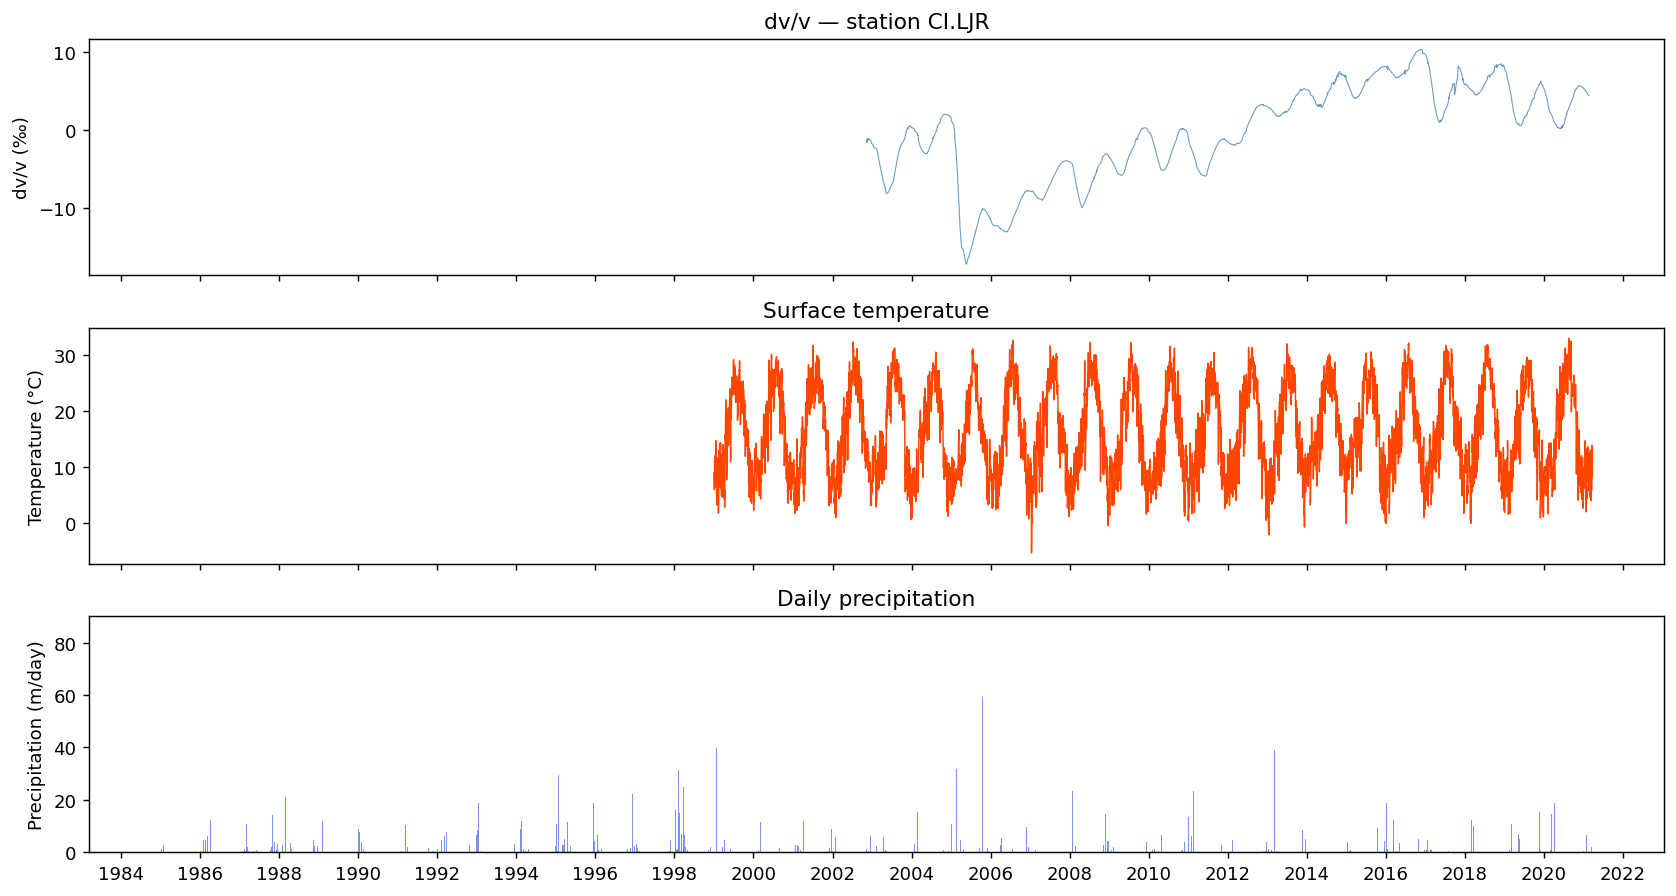

In [18]:
fig, axes = plt.subplots(3, 1, figsize=(13, 7), sharex=True)

axes[0].plot(dvv_data.index, dvv_data["dvv"] * 1e3, color="steelblue", lw=0.6, alpha=0.8)
axes[0].set_ylabel("dv/v (\u2030)")
axes[0].set_title(f"dv/v \u2014 station {STATION}")

if "temperature" in forcings:
    axes[1].plot(forcings["temperature"].index, forcings["temperature"].values,
                 color="orangered", lw=0.8)
axes[1].set_ylabel("Temperature (\u00b0C)")
axes[1].set_title("Surface temperature")

if "precipitation" in forcings:
    axes[2].bar(forcings["precipitation"].index,
                forcings["precipitation"].values,
                width=1.0, color="royalblue", alpha=0.7)
axes[2].set_ylabel("Precipitation (m/day)")
axes[2].set_title("Daily precipitation")

for ax in axes:
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
    ax.xaxis.set_major_locator(mdates.YearLocator(2))

fig.tight_layout()
plt.show()

## 4 · Run the six-phase `codameter` workflow

In [19]:
result = run_workflow(dvv_data, forcings or None, site)
print(result.summary())

=== codameter result for site 'cd2023_CI_LJR' ===

Phase 0  Data:    n=6596 samples, outliers=0
Phase 1  Kernel:  fc=2.83 Hz -> peak depth = 94 m  (mu=1.3 GPa, K=6.6 GPa)
Phase 2  Coupling: Pe=3550.23 -> safe; escalate=False
Phase 3  Design:  forcings=['hydrological', 'thermoelastic'], n_par=3
           Model:   dv/v(t) = a0 + p(p1_dGWL)*f_p1_dGWL(t) + p(p2_T)*f_p2_T(t) + eps(t)
Phase 4  Fit:     chi2_red=25.71, rank=3/3
           a0                     = -2.827e-04 +/- 1.23e-05
           p1_dGWL                = -2.220e-06 +/- 8.67e-09
           p2_T                   = -3.618e-05 +/- 1.64e-06
Phase 5  Anomaly: whiteness p=0.000, transients=0
Phase 6  Interp:  d(dv/v)/dp = -2.26e-10 +/- 8.84e-13 1/Pa
           mu_prime  = +1 +/- 0


## 4b · Hydrological model comparison

Four physical regimes are available:

| Model key | Governing equation | Key parameters |
|---|---|---|
| `"okubo_gwl"` | Exponential-decay GWL proxy (Okubo et al. 2024 Eq. 4) | `decay_rate_per_s` |
| `"talwani"` | Full Biot convolution — undrained erf + drained erfc (C&D 2023 Eq. 9) | `depth_m`, `diffusivity_m2_s`, `skempton_B` |
| `"drained"` | Drained-only erfc term — appropriate when Skempton's B ≈ 0 | `depth_m`, `diffusivity_m2_s` |
| `"cdm"` | Cumulative Departure from k-day rolling Mean (C&D 2023 CDMk) | `window_days` |

**C&D (2023) use `depth_m = 500 m` for all Talwani/drained models.**

The cell below runs all four and compares χ²_red. For CDM, the PRISM record from
1985-01-01 is prepended as a warmup so the rolling mean is properly initialised before
the first dv/v observation.

In [20]:
import dataclasses

HYDRO_MODELS = ["okubo_gwl", "talwani", "drained", "cdm"]

# C&D (2023) use depth_m=500 m for all convolution models.
# CDM window = 8 years as in the paper.
_hydro_extra = {
    "decay_rate_per_s": 1.0 / (180 * 86400),   # okubo_gwl
    "depth_m": 500.0,                            # talwani / drained (C&D 2023)
    "diffusivity_m2_s": 0.01,
    "skempton_B": 0.6,
    "poisson_undrained": 0.3,
    "window_days": 365 * 8,                      # cdm
}

# --- CDM warmup: PRISM days before the first dv/v observation ---
cdm_warmup_precip: np.ndarray | None = None
if real:
    dvv_start = dvv_data.index[0]
    ppt_sorted = ppt.sort_index()
    warmup_series = ppt_sorted[ppt_sorted.index < dvv_start]
    if len(warmup_series) > 0:
        cdm_warmup_precip = warmup_series.values.astype(float)
        print(f"CDM warmup: {len(cdm_warmup_precip)} days "
              f"({warmup_series.index[0].date()} → {warmup_series.index[-1].date()})")
    else:
        print("No warmup data available — CDM will use on-range initialisation")

model_results: dict[str, object] = {}
for model_key in HYDRO_MODELS:
    _site = dataclasses.replace(
        site,
        forcings=dataclasses.replace(
            site.forcings,
            hydrological=dataclasses.replace(
                site.forcings.hydrological,
                model=model_key,
                extra=_hydro_extra,
            ),
        ),
    )
    warmup = cdm_warmup_precip if model_key == "cdm" else None
    r = run_workflow(dvv_data, forcings or None, _site,
                     precipitation_warmup_m=warmup)
    model_results[model_key] = r
    chi2 = r.phase4.fit.chi2_reduced
    p1 = r.phase4.fit.posterior.mean[r.phase4.fit.parameter_names.index("p1_dGWL")]
    print(f"{model_key:<12}  chi2_red={chi2:7.2f}  p1_dGWL={p1: .3e}")

CDM warmup: 6524 days (1985-01-01 → 2002-11-11)
okubo_gwl     chi2_red=  25.71  p1_dGWL=-2.220e-06
talwani       chi2_red=  22.93  p1_dGWL=-2.299e-09
drained       chi2_red=  30.16  p1_dGWL=-1.742e-09
cdm           chi2_red=   1.78  p1_dGWL=-2.694e-05


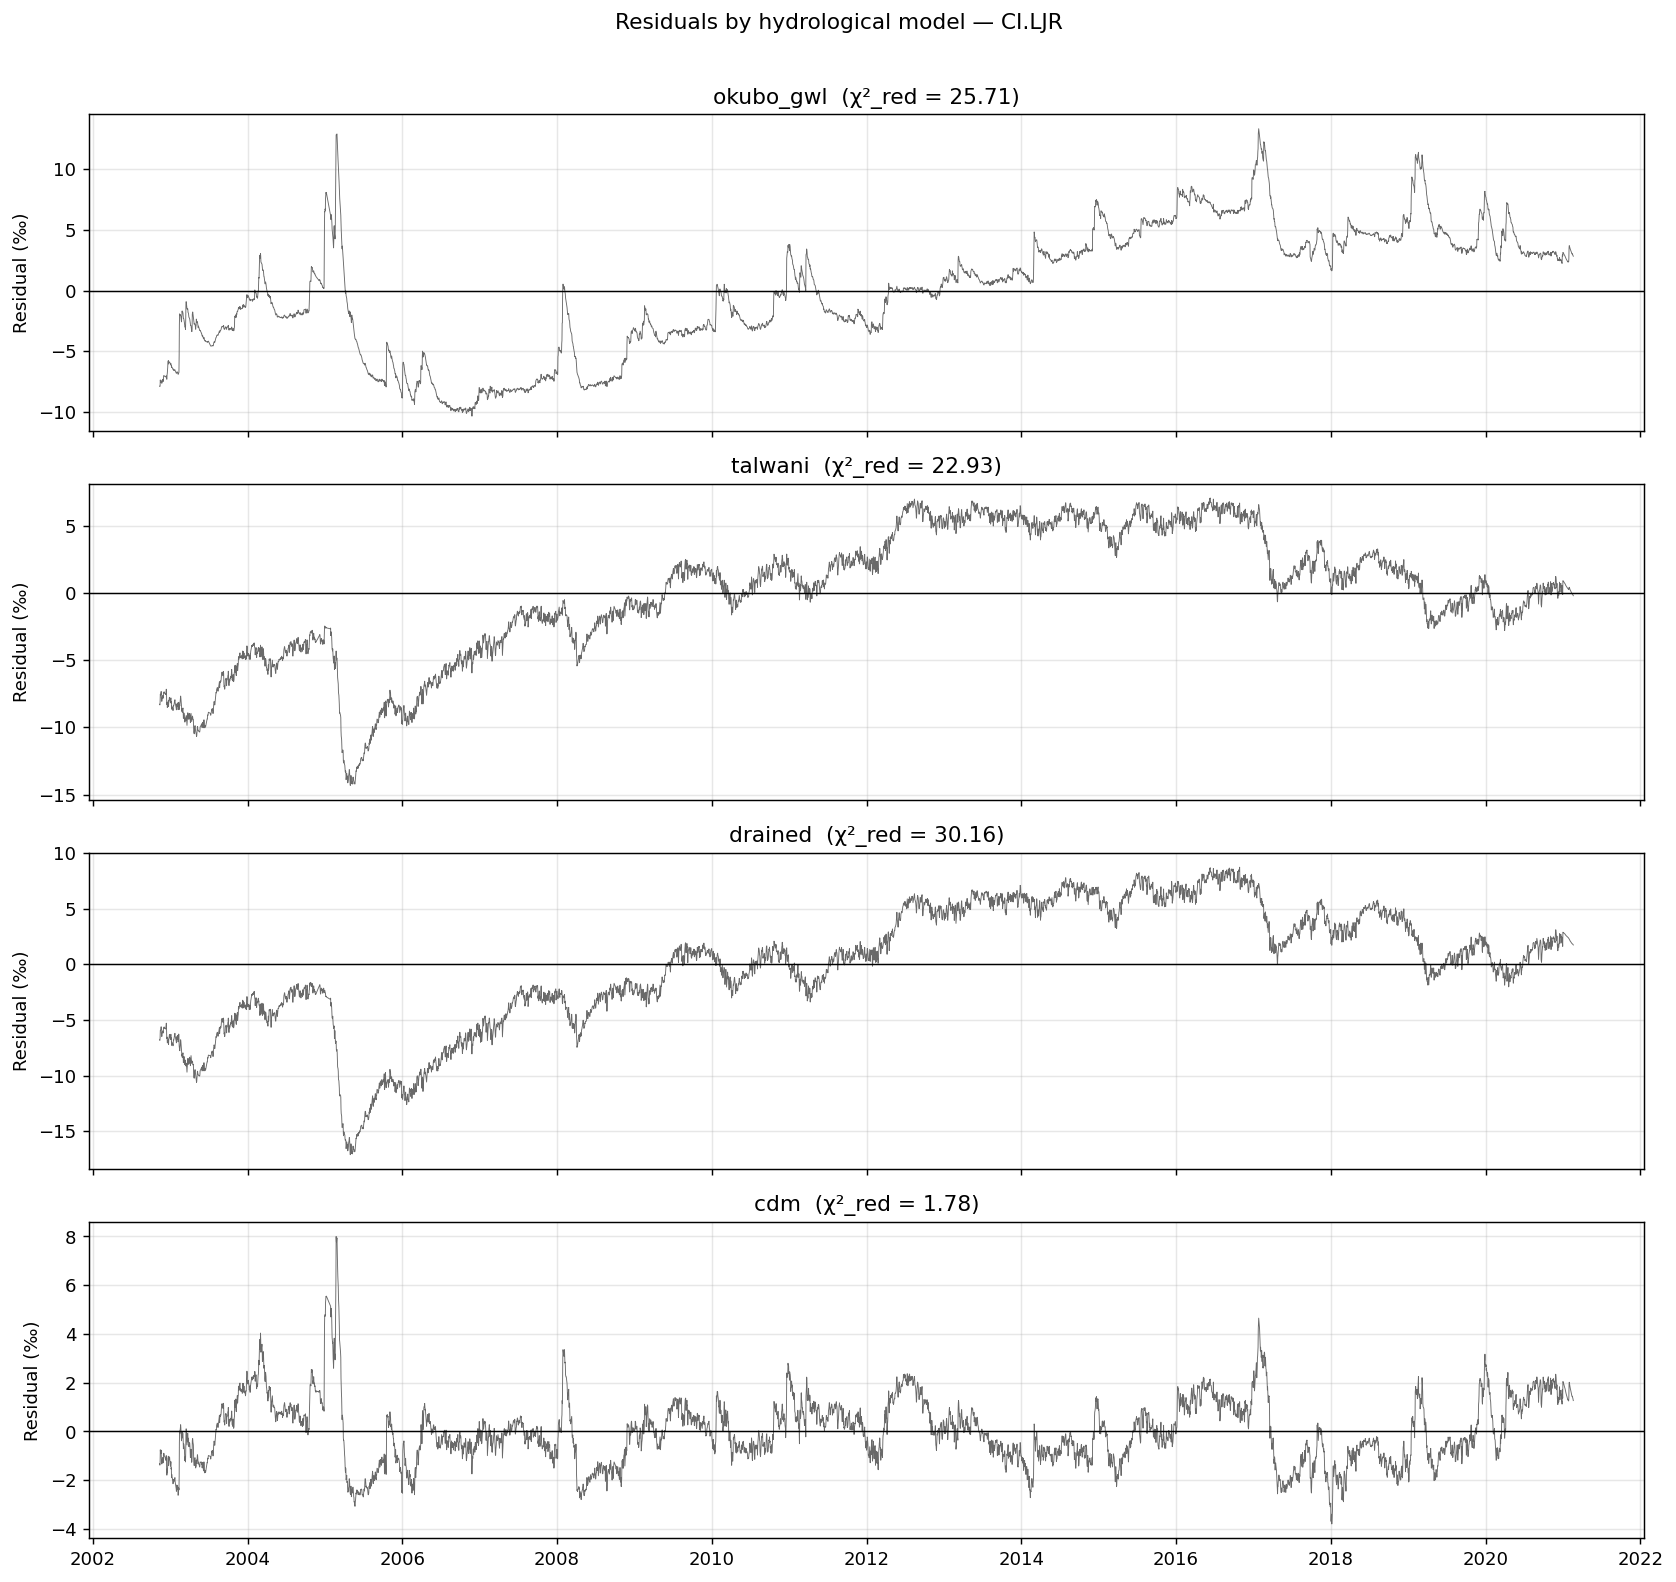

In [21]:
fig, axes = plt.subplots(len(HYDRO_MODELS), 1, figsize=(13, 3 * len(HYDRO_MODELS)), sharex=True)
for ax, model_key in zip(axes, HYDRO_MODELS):
    r = model_results[model_key]
    fit = r.phase4.fit
    res = pd.Series(fit.residuals, index=dvv_data.index[:len(fit.residuals)])
    ax.plot(res.index, res.values * 1e3, lw=0.5, color="dimgray")
    ax.axhline(0, lw=0.8, color="k")
    chi2 = fit.chi2_reduced
    ax.set_ylabel("Residual (‰)")
    ax.set_title(f"{model_key}  (χ²_red = {chi2:.2f})")
    ax.grid(True, alpha=0.3)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle(f"Residuals by hydrological model — CI.LJR", y=1.01)
fig.tight_layout()
plt.show()

## 4c · Diffusivity scan for Talwani / drained models

The hydraulic diffusivity *c* sets the pore-pressure diffusion timescale
τ = r²/(4πc).  Clements & Denolle (2023) optimise *c* in [5×10⁻⁵, ∞] m²/s.
We grid-search over a log-spaced range and report χ²_red for each value.

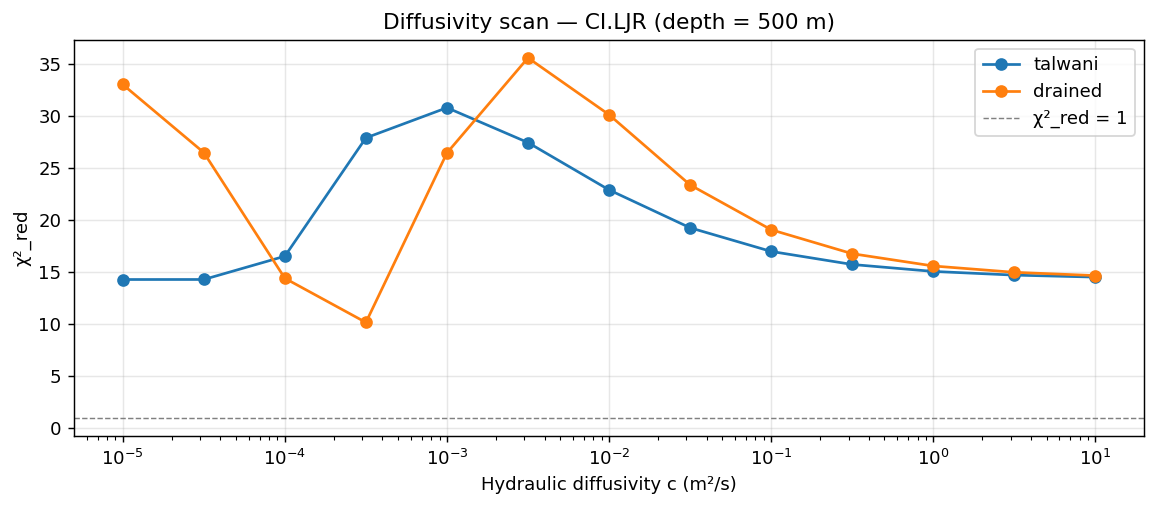

talwani     best c = 1.00e-05 m²/s  χ²_red = 14.31
drained     best c = 3.16e-04 m²/s  χ²_red = 10.19


In [22]:
DIFF_VALUES = np.logspace(-5, 1, 13)  # 5e-5 → 10 m²/s, 13 points
SCAN_MODELS = ["talwani", "drained"]

scan_results: dict[str, list[float]] = {m: [] for m in SCAN_MODELS}

for diff_c in DIFF_VALUES:
    _extra_scan = dict(_hydro_extra, diffusivity_m2_s=float(diff_c))
    for model_key in SCAN_MODELS:
        _site_scan = dataclasses.replace(
            site,
            forcings=dataclasses.replace(
                site.forcings,
                hydrological=dataclasses.replace(
                    site.forcings.hydrological,
                    model=model_key,
                    extra=_extra_scan,
                ),
            ),
        )
        r_scan = run_workflow(dvv_data, forcings or None, _site_scan)
        scan_results[model_key].append(r_scan.phase4.fit.chi2_reduced)

fig, ax = plt.subplots(figsize=(9, 4))
for model_key in SCAN_MODELS:
    ax.semilogx(DIFF_VALUES, scan_results[model_key], "o-", label=model_key)
ax.axhline(1.0, ls="--", color="gray", lw=0.8, label="χ²_red = 1")
ax.set_xlabel("Hydraulic diffusivity c (m²/s)")
ax.set_ylabel("χ²_red")
ax.set_title("Diffusivity scan — CI.LJR (depth = 500 m)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# print minimum
for model_key in SCAN_MODELS:
    best_idx = int(np.argmin(scan_results[model_key]))
    print(f"{model_key:<10}  best c = {DIFF_VALUES[best_idx]:.2e} m²/s  "
          f"χ²_red = {scan_results[model_key][best_idx]:.2f}")

## 4d · Select best model and refit

Pick the lowest χ²_red across all models (including CDM) and the optimally-scanned
diffusivity for convolution models, then re-run to overwrite `result` for the
downstream diagnostic cells.

In [23]:
# --- Collect all chi2_red values in one place ---
all_chi2: dict[str, float] = {k: v.phase4.fit.chi2_reduced for k, v in model_results.items()}

# Add scan minima for talwani / drained
for scan_model in SCAN_MODELS:
    best_scan_idx = int(np.argmin(scan_results[scan_model]))
    scan_key = f"{scan_model}@c={DIFF_VALUES[best_scan_idx]:.2e}"
    all_chi2[scan_key] = scan_results[scan_model][best_scan_idx]

print("χ²_red summary:")
for k, v in sorted(all_chi2.items(), key=lambda x: x[1]):
    print(f"  {k:<30}  {v:.2f}")

# --- Pick overall winner ---
best_key = min(all_chi2, key=all_chi2.__getitem__)
print(f"\nBest: {best_key}  (χ²_red = {all_chi2[best_key]:.2f})")

# --- Re-run workflow with best configuration ---
if "@c=" in best_key:
    # convolution model with optimal diffusivity
    best_model = best_key.split("@")[0]
    best_diff = float(best_key.split("c=")[1])
    _best_extra = dict(_hydro_extra, diffusivity_m2_s=best_diff)
else:
    best_model = best_key
    _best_extra = dict(_hydro_extra)

best_site = dataclasses.replace(
    site,
    forcings=dataclasses.replace(
        site.forcings,
        hydrological=dataclasses.replace(
            site.forcings.hydrological,
            model=best_model,
            extra=_best_extra,
        ),
    ),
)
warmup_best = cdm_warmup_precip if best_model == "cdm" else None
result = run_workflow(dvv_data, forcings or None, best_site,
                      precipitation_warmup_m=warmup_best)

print(f"\nresult overwritten with best model: {best_model}")
print(result.summary())

χ²_red summary:
  cdm                             1.78
  drained@c=3.16e-04              10.19
  talwani@c=1.00e-05              14.31
  talwani                         22.93
  okubo_gwl                       25.71
  drained                         30.16

Best: cdm  (χ²_red = 1.78)

result overwritten with best model: cdm
=== codameter result for site 'cd2023_CI_LJR' ===

Phase 0  Data:    n=6596 samples, outliers=0
Phase 1  Kernel:  fc=2.83 Hz -> peak depth = 94 m  (mu=1.3 GPa, K=6.6 GPa)
Phase 2  Coupling: Pe=3550.23 -> safe; escalate=False
Phase 3  Design:  forcings=['hydrological', 'thermoelastic'], n_par=3
           Model:   dv/v(t) = a0 + p(p1_dGWL)*f_p1_dGWL(t) + p(p2_T)*f_p2_T(t) + eps(t)
Phase 4  Fit:     chi2_red=1.78, rank=3/3
           a0                     = -2.809e-04 +/- 1.23e-05
           p1_dGWL                = -2.694e-05 +/- 5.70e-08
           p2_T                   = -7.710e-05 +/- 1.59e-06
Phase 5  Anomaly: whiteness p=0.000, transients=0
Phase 6  Interp:  d(d

## 5 · Diagnostic six-panel figure

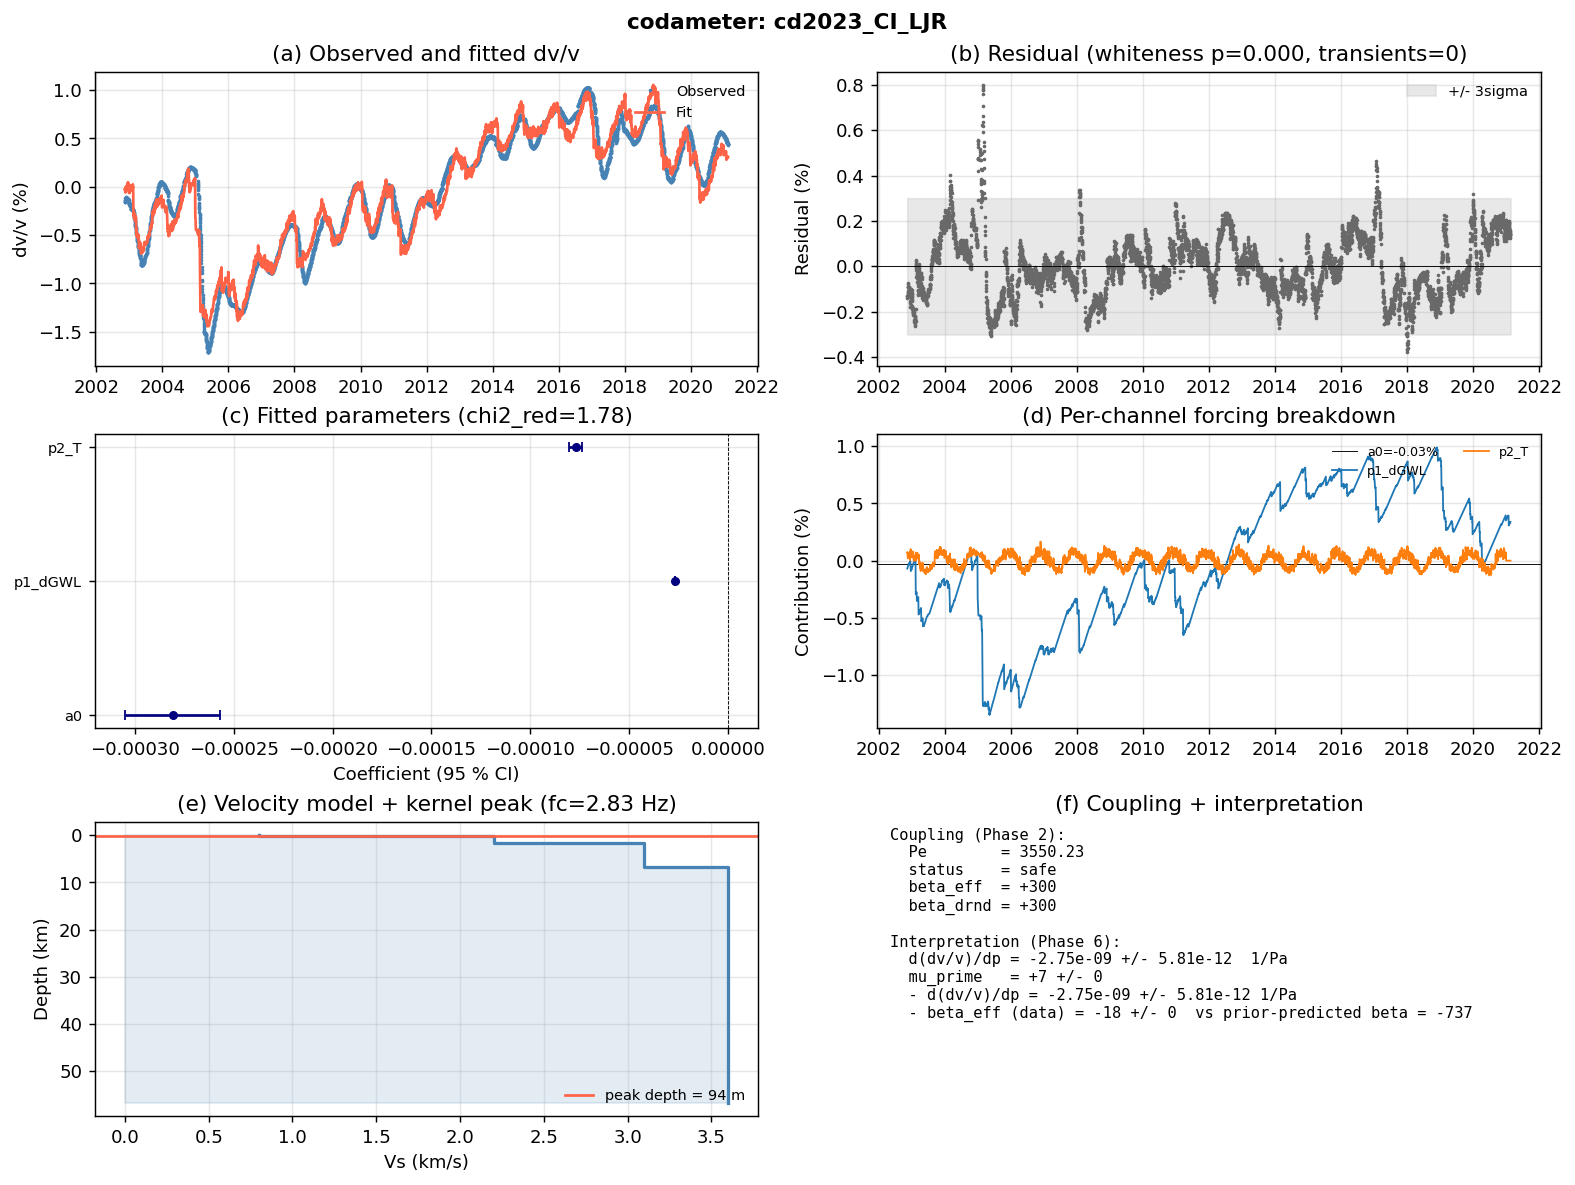

In [24]:
fig = result.plot_phases()
plt.show()

## 6 · Recovery check (synthetic mode only)

In [25]:
chi2 = result.phase4.fit.chi2_reduced
print(f"chi\u00b2_red = {chi2:.3f}  (ideal \u2248 1.0)")

if truth is not None:
    print("\nRecovery check:")
    for name, true_val in truth.items():
        try:
            m, s = result.phase4.fit.posterior.marginal(name)
        except KeyError:
            print(f"  {name}: not in posterior (parameter name mismatch?)")
            continue
        z = (m - true_val) / s if s > 0 else float("inf")
        flag = "\u2705 OK" if abs(z) < 4 else "\u274c FAIL"
        print(f"  {name:<12s}  truth={true_val:+.3e}  "
              f"fit={m:+.3e} \u00b1 {s:.2e}  z={z:+.2f}  {flag}")
else:
    print("(Real-data mode \u2014 no truth values to compare against)")

chi²_red = 1.781  (ideal ≈ 1.0)
(Real-data mode — no truth values to compare against)


## 7 · Export artefacts to disk

In [26]:
result.export(OUT_DIR)
print(f"Artefacts written to {OUT_DIR.resolve()}")
for p in sorted(OUT_DIR.iterdir()):
    if p.is_file():
        print(f"  {p.name}")

Artefacts written to /Users/marinedenolle/GitHub/codameter/examples/runs/cd2023_real
  parameters.csv
  residuals.csv
  results.json
  summary.txt
